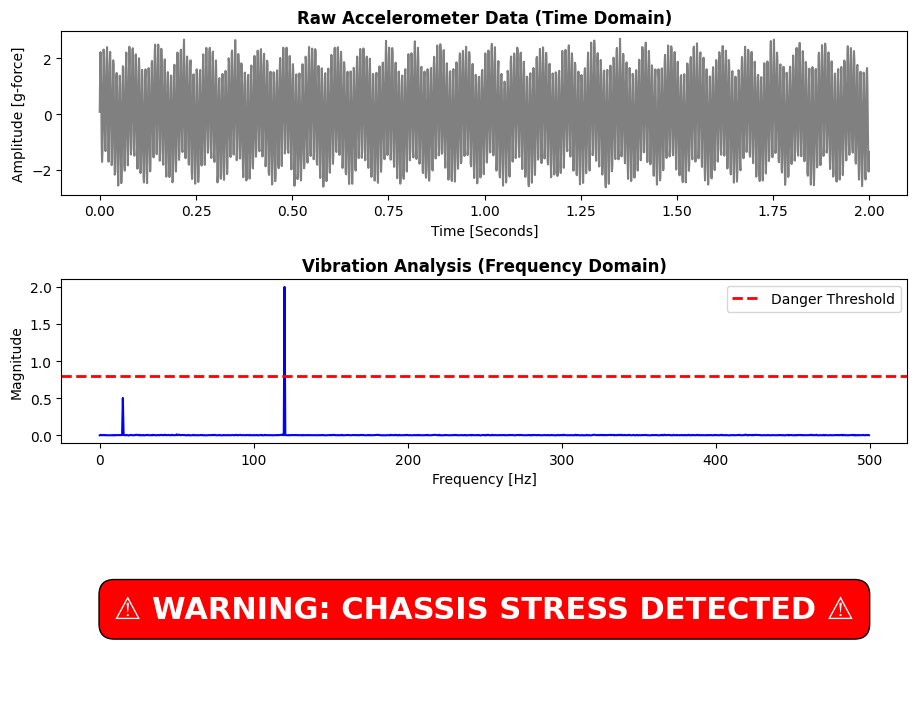

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- 1. Simulate Sensor Data Collection ---
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 2, 2 * fs, endpoint=False)  # 2 seconds of real-time data

# Simulate normal varying loads and vibrations (e.g., engine hum, road noise)
normal_vibration = 0.5 * np.sin(2 * np.pi * 15 * t) + np.random.normal(0, 0.1, len(t))

# Simulate a structural defect (e.g., high-frequency chatter from a crack or loose joint)
crack_signature = 2.0 * np.sin(2 * np.pi * 120 * t)
sensor_data = normal_vibration + crack_signature

# --- 2. Microcontroller Data Processing ---
def analyze_chassis_vibration(signal, fs, threshold):
    # Perform Fast Fourier Transform (FFT) to isolate frequency patterns
    # N is the number of samples in the signal.
    N = len(signal)
    # yf contains the complex FFT output.
    yf = fft(signal)
    # xf contains the corresponding frequencies for each FFT component.
    xf = fftfreq(N, 1 / fs)[:N//2]
    # magnitudes calculates the amplitude of each frequency component.
    magnitudes = 2.0/N * np.abs(yf[0:N//2])

    # Isolate abnormal high-frequency patterns (e.g., above 100 Hz)
    # We are interested in frequencies above 100 Hz to detect potential issues.
    high_freq_mags = magnitudes[xf > 100]
    # max_stress_vibration finds the peak magnitude in the high-frequency range.
    max_stress_vibration = np.max(high_freq_mags) if len(high_freq_mags) > 0 else 0

    # Determine if vibration exceeds the safety threshold
    # If the maximum high-frequency vibration exceeds the threshold, an alert is triggered.
    is_damaged = max_stress_vibration > threshold
    return xf, magnitudes, is_damaged

# Run the analysis against a defined safety threshold
safety_threshold = 0.8
xf, magnitudes, alert_triggered = analyze_chassis_vibration(sensor_data, fs, safety_threshold)

# --- 3. Display Expected Outcome (Dashboard Visualization) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
fig.tight_layout(pad=4.0)

# Plot A: Time Domain (Raw Accelerometer Data)
ax1.plot(t, sensor_data, color='gray')
ax1.set_title("Raw Accelerometer Data (Time Domain)", fontweight='bold')
ax1.set_xlabel("Time [Seconds]")
ax1.set_ylabel("Amplitude [g-force]")

# Plot B: Frequency Domain (Processed Data)
ax2.plot(xf, magnitudes, color='blue')
ax2.axhline(safety_threshold, color='red', linestyle='--', linewidth=2, label="Danger Threshold")
ax2.set_title("Vibration Analysis (Frequency Domain)", fontweight='bold')
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Magnitude")
ax2.legend()

# Plot C: Safety Telltale Indicator
ax3.axis('off')
if alert_triggered:
    ax3.text(0.5, 0.5, '⚠️ WARNING: CHASSIS STRESS DETECTED ⚠️',
             horizontalalignment='center', verticalalignment='center',
             fontsize=22, color='white', backgroundcolor='red', weight='bold',
             bbox=dict(facecolor='red', edgecolor='black', boxstyle='round,pad=0.5'))
else:
    ax3.text(0.5, 0.5, '✅ CHASSIS STRUCTURAL INTEGRITY NORMAL',
             horizontalalignment='center', verticalalignment='center',
             fontsize=22, color='white', backgroundcolor='green', weight='bold',
             bbox=dict(facecolor='green', edgecolor='black', boxstyle='round,pad=0.5'))

plt.show()

## Experiment: Testing Threshold Sensitivity with Simulated Noise

Adjust the `noise_amplitude` below to observe how the system's ability to detect the structural issue changes. This helps in understanding the sensitivity of the `safety_threshold`.

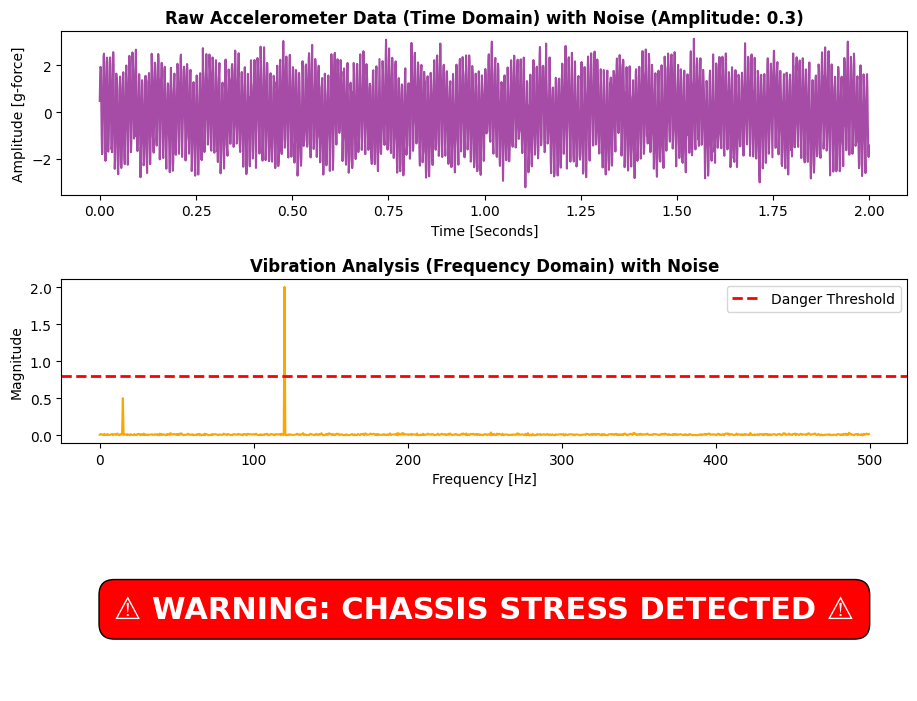

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- Configuration for Noise Simulation ---
noise_amplitude = 0.3 # @param {type:"number"} Adjust this value (e.g., 0.1, 0.5, 1.0)

# --- 1. Simulate Sensor Data Collection with additional noise ---
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 2, 2 * fs, endpoint=False)  # 2 seconds of real-time data

# Simulate normal varying loads and vibrations
normal_vibration = 0.5 * np.sin(2 * np.pi * 15 * t) + np.random.normal(0, 0.1, len(t))

# Simulate a structural defect
crack_signature = 2.0 * np.sin(2 * np.pi * 120 * t)

# Add simulated random noise to the sensor data
simulated_noise = np.random.normal(0, noise_amplitude, len(t))
sensor_data_with_noise = normal_vibration + crack_signature + simulated_noise

# --- 2. Microcontroller Data Processing (using the existing function) ---
# The analyze_chassis_vibration function is defined in the previous cell.
safety_threshold = 0.8 # Using the same threshold as before
xf_noise, magnitudes_noise, alert_triggered_noise = analyze_chassis_vibration(sensor_data_with_noise, fs, safety_threshold)

# --- 3. Display Expected Outcome (Dashboard Visualization) with Noise ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
fig.tight_layout(pad=4.0)

# Plot A: Time Domain (Raw Accelerometer Data with Noise)
ax1.plot(t, sensor_data_with_noise, color='purple', alpha=0.7)
ax1.set_title(f"Raw Accelerometer Data (Time Domain) with Noise (Amplitude: {noise_amplitude})", fontweight='bold')
ax1.set_xlabel("Time [Seconds]")
ax1.set_ylabel("Amplitude [g-force]")

# Plot B: Frequency Domain (Processed Data with Noise)
ax2.plot(xf_noise, magnitudes_noise, color='orange')
ax2.axhline(safety_threshold, color='red', linestyle='--', linewidth=2, label="Danger Threshold")
ax2.set_title("Vibration Analysis (Frequency Domain) with Noise", fontweight='bold')
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Magnitude")
ax2.legend()

# Plot C: Safety Telltale Indicator with Noise
ax3.axis('off')
if alert_triggered_noise:
    ax3.text(0.5, 0.5, '⚠️ WARNING: CHASSIS STRESS DETECTED ⚠️',
             horizontalalignment='center', verticalalignment='center',
             fontsize=22, color='white', backgroundcolor='red', weight='bold',
             bbox=dict(facecolor='red', edgecolor='black', boxstyle='round,pad=0.5'))
else:
    ax3.text(0.5, 0.5, '✅ CHASSIS STRUCTURAL INTEGRITY NORMAL',
             horizontalalignment='center', verticalalignment='center',
             fontsize=22, color='white', backgroundcolor='green', weight='bold',
             bbox=dict(facecolor='green', edgecolor='black', boxstyle='round,pad=0.5'))

plt.show()

# Project Report: Chassis Structural Integrity Monitoring

This notebook demonstrates a simulated system for monitoring chassis structural integrity using vibration analysis. The core idea is to detect potential structural issues, such as cracks or loose joints, by analyzing specific frequency patterns in vibration data collected from sensors.

## Key Components and Demonstrations:

### 1. Raw Data Simulation and Structural Defect Introduction

*   **Purpose**: To mimic real-world sensor data from a vehicle's chassis and introduce a simulated structural defect.
*   **Methodology**: Vibration data is generated over a 2-second period with a sampling frequency of 1000 Hz.
    *   `normal_vibration`: Simulates ambient vibrations from typical vehicle operation (engine hum, road noise).
    *   `crack_signature`: A high-frequency sinusoidal wave (120 Hz) is added to represent the unique vibration signature of a structural defect.
*   **Visualization**: The "Raw Accelerometer Data (Time Domain)" plot (top graph in the initial output) shows this combined signal, appearing chaotic due to the mix of normal and defect-induced vibrations.

### 2. Microcontroller Data Processing (Vibration Analysis)

*   **Function**: `analyze_chassis_vibration(signal, fs, threshold)`
*   **Process**: This function simulates the processing capability of a microcontroller:
    1.  **Fast Fourier Transform (FFT)**: Applied to the raw time-domain signal to convert it into the frequency domain. This allows for the identification of specific vibration frequencies and their magnitudes.
    2.  **High-Frequency Pattern Isolation**: The system focuses on frequencies above 100 Hz, as structural defects often manifest as higher-frequency vibrations.
    3.  **Threshold Comparison**: The maximum magnitude of these high-frequency components is compared against a predefined `safety_threshold` (e.g., 0.8).
*   **Visualization**: The "Vibration Analysis (Frequency Domain)" plot (middle graph) clearly shows frequency spikes. A prominent spike around 120 Hz indicates the detected defect. The red dashed line visually represents the `safety_threshold`.

### 3. Safety Telltale Indicator

*   **Purpose**: To provide a clear and immediate warning to the user or driver.
*   **Mechanism**: If the maximum high-frequency vibration magnitude crosses the `safety_threshold`, a visual alert is triggered.
*   **Visualization**: The "Safety Telltale Indicator" (bottom display) shows either a '⚠️ WARNING: CHASSIS STRESS DETECTED ⚠️' message in red or '✅ CHASSIS STRUCTURAL INTEGRITY NORMAL' in green, depending on the analysis result.

### 4. Noise Sensitivity Testing

*   **Purpose**: To evaluate the robustness of the system's detection capabilities under varying levels of environmental noise.
*   **Methodology**: An additional, tunable `noise_amplitude` parameter (`0.3` by default) is introduced to generate random noise, which is then added to the sensor data.
*   **Experimentation**: By adjusting the `noise_amplitude`, users can observe how the system's ability to detect the crack signature changes. This helps in calibrating the `safety_threshold` to balance sensitivity (detecting true defects) and robustness (avoiding false positives from noise).
*   **Observation**: The plots generated during noise simulation illustrate how the raw data becomes more erratic, but the FFT still isolates the critical 120 Hz spike, and the telltale indicator updates based on whether this spike (with noise) still crosses the threshold.